In [5]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt # THIS ISN't FUNCTIONAL, IT's JUST TEMPORARY
import time
words = open('names.txt', 'r').read().splitlines()

In [6]:
class Value:
    def __init__(self, data, _children=(), _opp="", label=""):
        self.data = np.array(data)
        self.prev = set(_children)
        self.grad = np.zeros_like(self.data, dtype=float)
        self.opp = _opp
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #Make it still work if other is an integer and not a Value (a+1, for instance)
        
        def _unbroadcast(grad, shape):
            # sum over axes that were broadcast
            while grad.ndim > len(shape):
                grad = grad.sum(axis=0)
            for i, dim in enumerate(shape):
                if dim == 1:
                    grad = grad.sum(axis=i, keepdims=True)
            return grad
        
        def _backward():
            self.grad += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)

        out = Value(self.data+other.data, (self, other), "+")
        out._backward = _backward
        return out
    
    def __matmul__(self, other):
        out = Value(self.data @ other.data, (self, other), "@")
        def _backward():
            self.grad += out.grad @ other.data.T
            other.grad += self.data.T @ out.grad
        
        out._backward = _backward
        
        return out
    
    def __radd__(self, other):
        return self + other

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __mul__(self, other):
        def _unbroadcast(grad, shape):
            # sum over axes that were broadcast
            while grad.ndim > len(shape):
                grad = grad.sum(axis=0)
            for i, dim in enumerate(shape):
                if dim == 1:
                    grad = grad.sum(axis=i, keepdims=True)
            return grad


        other = other if isinstance(other, Value) else Value(other)
        def _backward():
            self.grad += _unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += _unbroadcast(self.data * out.grad, other.data.shape)

        out = Value(self.data * other.data, (self, other), "*")
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
        #Add support for integer * Value (since 2*a doesn't work, but a*2 does)
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "not an int or float"
        out = Value(self.data**other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __len__(self):
        return len(self.data)
    
    def tanh(self):
        x=self.data
        t = np.tanh(x)

        def _backward():
            self.grad += (1-t**2) * out.grad

        out = Value(t, (self, ), "tanh")
        out._backward=_backward
        return out
    
    def exp(self):
        x=self.data

        def _backward():
            self.grad += (np.exp(x)*out.data)

        out = Value(np.exp(x), (self, ), "exp")
        out._backward=_backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = np.ones_like(self.data)

        for node in reversed(topo):
            node._backward()

#Helper function
def oneHot(c):
    out = [0 for _ in range(27)]
    curIndex = ord(c)-97
    if curIndex <0:
        curIndex=26 # Change it if it's a period
    out[curIndex] = 1
    return out
def cross_entropy(logits, targets):
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    
    correct_probs = probs[np.arange(len(targets)), targets]
    loss = -np.log(correct_probs).mean()
    
    out = Value(loss, (logits,), "cross_entropy")
    
    def _backward():
        # gradient of cross entropy + softmax combined is just (probs - 1_correct) / batch_size
        dlogits = probs.copy()
        dlogits[np.arange(len(targets)), targets] -= 1
        dlogits /= len(targets)
        logits.grad += dlogits
    
    out._backward = _backward
    return out
def prog(val, total):
    length = 20
    out = "["
    for i in range(length):
        if i < math.ceil((val/total) * length):
            out += "#"
        else:
            out += "-"
    return out + "]"
def trunc(number, digits):
    stepper = 10 ** digits
    return math.trunc(number * stepper) / stepper


In [7]:
# defining weights
W1 = Value(np.random.randn(30, 200) * (5/3) / (30**0.5))  # embedding_size * block_size -> hidden
#b1 = Value(np.zeros(200))
W2 = Value(np.random.randn(200, 27) * 0.01)  # hidden -> logits 
b2 = Value(np.zeros(27))
charEncodings = Value(np.random.randn(27,10)) #Increase to 10 dimensional embeddings
bngain = Value(np.ones((1, 200)))
bnbias = Value(np.zeros((1, 200)))

parameters = [charEncodings, W1, W2, b2, bngain, bnbias] # for easy access during 
finished = 0
lossGraph=[]
bnmean_running = Value(np.zeros((1, 200)))
bnstd_running = Value(np.ones((1, 200)))

In [8]:
stoi = {s:i for i,s in enumerate(sorted(list(set(''.join(words)))))}
stoi['.']=26
itos = {i:s for s,i in stoi.items()}

blockSize = 3
inputs, outputs = [],[]

In [9]:
for w in words:
    context = [0] * blockSize # start with 3 starting characters
    for ch in w + '.':
        ix = stoi[ch] # get the current character
        inputs.append(context) # add input to inputs, output to outputs
        outputs.append(ix)
        context = context[1:] + [ix] # update the context

In [10]:
n1 = int(.8 * len(inputs))
n2 = int(.9 * len(inputs))

trainIn = inputs[:n1] # Training data (80%)
trainOut = outputs[:n1]
devIn = inputs[n1:n2] # Development data (10%) For use on like testing random ideas, etc
devOut = outputs[n1:n2]
testIn = inputs[n2:] #  Test data (10%) 
testOut = outputs[n2:]

In [11]:
def forward(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 #+ b1 # Pre hidden layer Need to add batch normalization, which is when we standardize the hidden layer std.
    bnmeani = np.mean(h.data, 0)
    bnstdi = np.std(h.data, 0)
    h = (h - bnmeani) / (bnstdi + 1e-5) # Batch normalization! Prevents loss of data in the tanh function
    # The 1e-5 is an epsilon value to prevent division by zero! (ε)
    h = h * bngain + bnbias # Scale and shift the normalized values
    
    bnmean_running.data = 0.999 * bnmean_running.data + 0.001 * bnmeani
    bnstd_running.data = 0.999 * bnstd_running.data + 0.001 * bnstdi

    h = h.tanh() # Hidden layer
    logits = h @ W2 + b2

    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    #print(loss) 

    loss.backward()

    if epoch < 150000:
        lr = -.1
    else:
        lr = -.01

    for p in parameters:
        p.data += lr * p.grad
        p.grad = np.zeros_like(p.data, dtype=float)

def forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, inputs, outputs, epoch=0):
    # Encode the inputs
    batch = [random.randint(0, len(inputs)-1) for _ in range(32)] #  get 32 random indexes (indexii? indeces? idk)

    enc = [[0 for _ in range(len(inputs[0]))] for i in range(len(batch))]
  
    for input in range(len(batch)):
        for c in range(len(inputs[batch[input]])):
            enc[input][c] = charEncodings.data[inputs[batch[input]][c]]

    #resize the inputs
    for input in range(len(enc)):
        out = []
        for letter in enc[input]:
            out.extend(letter)
        enc[input] = out

    enc = Value(enc)

    # Now for the forward pass
    h = enc @ W1 #+b1
    h = (h - np.mean(h.data, 0)) / np.std(h.data, 0) #Added the batch normalization for the testing set
    h = h * bngain + bnbias
    h = h.tanh()
    logits = h @ W2 + b2


    # Now loss calculation
    loss = cross_entropy(logits, [outputs[x] for x in batch])

    return loss

In [12]:
epochs = 20000000
START_TIME = time.perf_counter()
print(f"Started training Makemore ({epochs} epochs)")
trainTemp = -1
testTemp = -1
for i in range(epochs):
    if (i%50==0):
        train_loss = trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, trainIn, trainOut, i).data, 3)
        test_loss  = trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)
        trainTemp, testTemp = train_loss, test_loss
        lossGraph.append(test_loss)
    else:
        train_loss = trainTemp
        test_loss = trainTemp
    forward(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, trainIn, trainOut, i)
    finished += 1
    print(f"\rTrained {i+1} epochs.", end="")

print(f"\nTotal Trained: {finished}")

Started training Makemore (20000000 epochs)
Trained 1827122 epochs.

KeyboardInterrupt: 

In [14]:
trunc(forwardNoTrain(Value, cross_entropy, W1, W2, b2, charEncodings, parameters, testIn,  testOut,  i).data, 3)

2.208

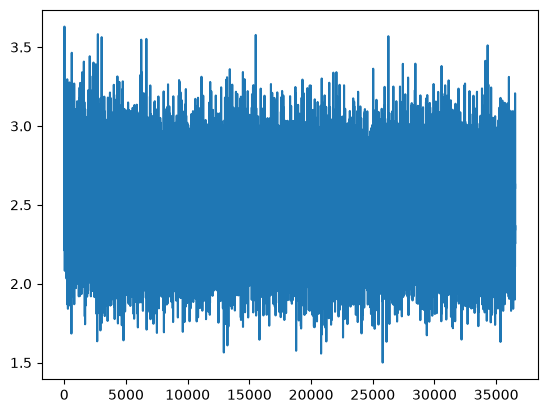

In [15]:
plt.plot(lossGraph)

In [ ]:
# Calibrate the batch norm for at the end of training so a single example can be used clearly.
# We no longer need this because we calculate a running total.

# Get the embeddings
# Get the preaction function
# Get the average and standard deviation of that preaction function

enc = [[0 for _ in range(len(trainIn[0]))] for i in range(len(trainIn))]
for input in range(len(trainIn)):
    for c in range(len(trainIn[input])):
        enc[input][c] = charEncodings.data[trainIn[input][c]]

for input in range(len(enc)):
    out = []
    for letter in enc[input]:
        out.extend(letter)
    enc[input] = out

enc = Value(enc)

hpreact = enc @ W1 # No b1

bnmean = np.mean(hpreact.data, 0, keepdims=True)
bnstd  = np.std(hpreact.data, 0, keepdims=True)

print(bnmean)
print(bnstd)

[[-2.38797503 -0.83315196  1.13450863 -1.3576185   1.36663867 -2.16317149
   2.88883113 -0.99394313  1.11960863 -1.32216218  1.26720161 -2.95456207
  -0.67753172  0.48354377 -0.44271106  3.16579142 -2.72330581 -1.35736425
   2.15276849 -0.21307623 -1.66776591 -0.62130134  0.72384381 -1.18870487
   2.00925524  0.87637068  0.12172464  0.98566319 -2.39637623  1.72571697
  -0.57622579 -0.73849219 -4.27404793 -0.70691346  1.02672964  4.22969208
   0.00894984  2.50783923  0.94815743  2.1671351   3.96629209  2.59400138
   1.18766497  3.13472731  1.24727749  1.17680586 -2.5825583   1.22250446
   0.38306356  0.0713405   2.96995494 -1.02870727 -1.2849251   0.97543092
   0.70051245  2.13023347  0.40245834 -0.04773773  0.45543863 -0.8537102
   0.3648567   2.46808159  0.48854826  0.48829179  1.50932657 -0.63955097
   1.31709896  0.37761006 -1.29344807 -0.20416241 -0.06304571  0.47054454
  -2.24750019 -0.09108737  0.26981561  0.01633858 -0.48550309 -1.090429
  -0.63286313 -1.96240117 -2.0422504  -0.

In [16]:
def predict():
    out = "..."

    #First pass
    enc = [[0,0,0]]
    for c in range(3):
        enc[0][c] = charEncodings.data[26] # THis is over the top bc I didn't want to redo everything, but it just puts in the index of starting character.

    #resize the inputs
    for input in range(len(enc)):
        flat = []
        for letter in enc[input]:
            flat.extend(letter)
        enc[input] = flat

    enc = Value(enc)

    h = enc @ W1
    h = (h - bnmean_running.data) / (bnstd_running.data + 1e-5)
    h = h * bngain + bnbias
    h = h.tanh()
    logits = h @ W2 + b2
    e = np.exp(logits.data)
    probs = e / e.sum(axis=1, keepdims=True)
    reverse = {v: k for k, v in stoi.items()}

    while len(out) < 50:
        # rest of name
        enc = [[0,0,0]]
        for c in range(3):
            enc[0][c] = charEncodings.data[stoi[out[-3+c]]]

        #resize the inputs
        for input in range(len(enc)):
            flat = []
            for letter in enc[input]:
                flat.extend(letter)
            enc[input] = flat

        enc = Value(enc)

        h = enc @ W1
        h = (h - bnmean_running.data) / (bnstd_running.data + 1e-5)
        h = h * bngain + bnbias
        h = h.tanh()
        logits = h @ W2 + b2
        e = np.exp(logits.data)
        probs = e / e.sum(axis=1, keepdims=True)
        reverse = {v: k for k, v in stoi.items()} 
        out += reverse[np.random.choice(27, p=probs[0])]
        if out[-1] == '.':
            break
    
    print(out[3:-1])

In [23]:
for i in range(20):
    predict()

a
an
ai
anthonna
eniseon
e
tta
tisa
ene
iad
i
abelle
i
easecilla
iff
id
ila
k

ine


In [ ]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = Value(np.random.randn(fan_in, fan_out) / fan_in**0.5)
        self.bias = Value(np.zeros(fan_out)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])



class BatchNorm1D:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained via backprop)
        self.gamma = Value(np.ones(dim))
        self.beta = Value(np.zeros(dim))
        # buffers (updated with a running average, not backprop)
        self.running_mean = np.zeros(dim)
        self.running_var = np.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = np.mean(x.data, axis=0, keepdims=True) # batch mean
            xvar = np.var(x.data, axis=0, keepdims=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / (xvar + self.eps) ** .5 # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = x.tanh()
        return self.out
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
vocab_size = 27

C = Value(np.random.randn(vocab_size, n_embd))
layers = [
  Linear(n_embd * blockSize, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1D(vocab_size),
]

# layers = [
#   Linear(n_embd * blockSize, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

# last layer: make less confident
layers[-1].gamma.data *= 0.1
# all other layers: apply gain
for layer in layers[:-1]:
    if isinstance(layer, Linear):
        layer.weight.data *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.data.size for p in parameters)) # number of parameters in total
